In [5]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats

from scipy.stats import shapiro, levene

import scikit_posthocs as sp

from scipy.stats import kruskal

from sklearn.decomposition import PCA

import numpy as np

import pickle

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7607.88it/s]


In [6]:

# carico i dataset
synonym_df = pd.read_csv("synonym_pairs_final.csv")
antonym_df = pd.read_csv("antonym_pairs_final.csv")
random_df = pd.read_csv("random_pairs_final.csv")


#codice da eseguire per avere gli embedding modello contestuale

import pickle

with open("embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [7]:
#Estrazione delle PCA (50,10,2 D)
#converto dizionario di embedding in una matrice Numpy
#creo una lista contenente le chiavi del dizionario
words = list(embeddings.keys())
#creo la matrice degli embedding vstack impila vettori e adatto tensor pytorch a numpy
embedding_matrix = np.vstack([
    embeddings[word].numpy()
    for word in words
])

print(embedding_matrix.shape)

(638, 384)


In [8]:
#PCA 50 D
pca_50 = PCA(n_components=50)
pca_50_embedding = pca_50.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 50 D:", pca_50_embedding.shape)
print("Varianza spiegata totale:", pca_50.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 50 D: (638, 50)
Varianza spiegata totale: 0.55772096


In [9]:
#PCA 10 D
pca_10 = PCA(n_components=10)
pca_10_embedding = pca_10.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 10 D:", pca_10_embedding.shape)
print("Varianza spiegata totale:", pca_10.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 10 D: (638, 10)
Varianza spiegata totale: 0.19610973


In [10]:
#PCA 2 D
pca_2 = PCA(n_components=2)
pca_2_embedding = pca_2.fit_transform(embedding_matrix)
print("Dimensione della matrice dopo PCA 2 D:", pca_2_embedding.shape)
print("Varianza spiegata totale:", pca_2.explained_variance_ratio_.sum())

Dimensione della matrice dopo PCA 2 D: (638, 2)
Varianza spiegata totale: 0.05459054


In [11]:
#riassunto:
print("Varianza spiegata totale di PCA 50 D:", pca_50.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 10 D:", pca_10.explained_variance_ratio_.sum())
print("Varianza spiegata totale di PCA 2 D:", pca_2.explained_variance_ratio_.sum())

Varianza spiegata totale di PCA 50 D: 0.55772096
Varianza spiegata totale di PCA 10 D: 0.19610973
Varianza spiegata totale di PCA 2 D: 0.05459054


In [12]:
#ricreo dizionari di embedding

diz_embeddings_pca_50 = {
    word: pca_50_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_10 = {
    word: pca_10_embedding [i]
    for i, word in enumerate(words)
}

diz_embeddings_pca_2 = {
    word: pca_2_embedding [i]
    for i, word in enumerate(words)
}

In [13]:
#rifaccio primo esperimento per le tre distribuzioni:


#funzione per la cosine similarity

def add_cosine_similarity(df, col1, col2, diz_embedding ):
    #in input entrano: il database delle coppie, la colonna della parola e la colonna della parola associata, il dizionario della PCA
    #si crea una lista  per i risultati della cosine similarity
    #si calcola la cosine similarity usando gli embedding già calcolati
    #si crea una colonna nel dataset di partenza con i risultati della cosine similarity
    
    similarities = []

    for w1, w2 in zip(df[col1], df[col2]):

        emb1 = embeddings[w1]
        emb2 = embeddings[w2]

        similarity = cos_sim(
            emb1,
            emb2
        ).item()

        similarities.append(similarity)


    df["cosine_similarity"] = similarities

    return df

In [14]:
#funzione per sinonimi

syn_df_50D = add_cosine_similarity(
    synonym_df,
    "word",
    "synonym",
    diz_embeddings_pca_50
)

syn_df_10D = add_cosine_similarity(
    synonym_df,
    "word",
    "synonym",
    diz_embeddings_pca_10
)

syn_df_2D = add_cosine_similarity(
    synonym_df,
    "word",
    "synonym",
    diz_embeddings_pca_2
)

print("Sinonimi PCA 50 D:\n" ,syn_df_50D.head() )
print("\n")
print("Sinonimi PCA 10 D:\n", syn_df_10D.head())
print("\n")
print("Sinonimi PCA 2 D:\n",syn_df_2D.head())

Sinonimi PCA 50 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.397232
1   ghastly      macabre  synonym           0.251190
2     dodgy        dicey  synonym           0.389690
3  biweekly  fortnightly  synonym           0.378817
4   pouring      gushing  synonym           0.522623


Sinonimi PCA 10 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.397232
1   ghastly      macabre  synonym           0.251190
2     dodgy        dicey  synonym           0.389690
3  biweekly  fortnightly  synonym           0.378817
4   pouring      gushing  synonym           0.522623


Sinonimi PCA 2 D:
        word      synonym relation  cosine_similarity
0  revolved      rotated  synonym           0.397232
1   ghastly      macabre  synonym           0.251190
2     dodgy        dicey  synonym           0.389690
3  biweekly  fortnightly  synonym           0.378817
4   pouring      gushing  synonym   

In [15]:
#funzione per contrari
ant_df_50D = add_cosine_similarity(
    antonym_df,
    "word",
    "antonym",
    diz_embeddings_pca_50
)

ant_df_10D = add_cosine_similarity(
    antonym_df,
    "word",
    "antonym",
    diz_embeddings_pca_10
)

ant_df_2D = add_cosine_similarity(
    antonym_df,
    "word",
    "antonym",
    diz_embeddings_pca_2
)

print("Contrari PCA 50 D:\n" ,ant_df_50D.head() )
print("\n")
print("Contrari PCA 10 D:\n", ant_df_10D.head())
print("\n")
print("Contrari PCA 2 D:\n",ant_df_2D.head())

Contrari PCA 50 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.814616
1  centralized  decentralized  antonym           0.613580
2   reasonable   unreasonable  antonym           0.696652
3       simple        complex  antonym           0.469160
4      legible      illegible  antonym           0.461158


Contrari PCA 10 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.814616
1  centralized  decentralized  antonym           0.613580
2   reasonable   unreasonable  antonym           0.696652
3       simple        complex  antonym           0.469160
4      legible      illegible  antonym           0.461158


Contrari PCA 2 D:
           word        antonym relation  cosine_similarity
0    ascending     descending  antonym           0.814616
1  centralized  decentralized  antonym           0.613580
2   reasonable   unreasonable  antonym           0.696652
3       s

In [16]:
#Random
rand_df_50D = add_cosine_similarity(
    random_df,
    "word",
    "random",
    diz_embeddings_pca_50
)

rand_df_10D = add_cosine_similarity(
    random_df,
    "word",
    "random",
    diz_embeddings_pca_10
)

rand_df_2D = add_cosine_similarity(
    random_df,
    "word",
    "random",
    diz_embeddings_pca_2
)

print("Random PCA 50 D:\n" ,rand_df_50D.head())
print("\n")
print("Random PCA 10 D:\n" ,rand_df_10D.head())
print("\n")
print("Random PCA 2 D:\n" ,rand_df_2D.head())

Random PCA 50 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.242246
1  unpalatable  melancholic   random           0.300340
2     obliging     definite   random           0.234148
3    punishing  recombinant   random           0.151135
4      opposed        ionic   random           0.161461


Random PCA 10 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.242246
1  unpalatable  melancholic   random           0.300340
2     obliging     definite   random           0.234148
3    punishing  recombinant   random           0.151135
4      opposed        ionic   random           0.161461


Random PCA 2 D:
           word       random relation  cosine_similarity
0     plodding    bombastic   random           0.242246
1  unpalatable  melancholic   random           0.300340
2     obliging     definite   random           0.234148
3    punishing  recombinant   random           

In [17]:
#salvo i risultati
syn_df_50D.to_csv(
    "results_synonyms_similarity_PCA50.csv",
    index=False
)

syn_df_10D.to_csv(
    "results_synonyms_similarity_PCA10.csv",
    index=False
)

syn_df_2D.to_csv(
    "results_synonyms_similarity_PCA2.csv",
    index=False
)

ant_df_50D.to_csv(
    "results_antonyms_similarity_PCA50.csv",
    index=False
)

ant_df_10D.to_csv(
    "results_antonyms_similarity_PCA10.csv",
    index=False
)

ant_df_2D.to_csv(
    "results_antonyms_similarity_PCA2.csv",
    index=False
)

rand_df_50D.to_csv(
    "results_random_similarity_PCA50.csv",
    index=False
)

rand_df_10D.to_csv(
    "results_random_similarity_PCA10.csv",
    index=False
)

rand_df_2D.to_csv(
    "results_random_similarity_PCA2.csv",
    index=False
)

In [18]:
#per caricare dataset con cosine similarity

syn_df_50D = pd.read_csv("results_synonyms_similarity_PCA50.csv")
syn_df_10D = pd.read_csv("results_synonyms_similarity_PCA10.csv")
syn_df_2D = pd.read_csv("results_synonyms_similarity_PCA2.csv")
ant_df_50D = pd.read_csv("results_antonyms_similarity_PCA50.csv")
ant_df_10D = pd.read_csv("results_antonyms_similarity_PCA10.csv")
ant_df_2D = pd.read_csv("results_antonyms_similarity_PCA2.csv")
rand_df_50D = pd.read_csv("results_random_similarity_PCA50.csv")
rand_df_10D = pd.read_csv("results_random_similarity_PCA10.csv")
rand_df_2D = pd.read_csv("results_random_similarity_PCA2.csv")

In [21]:
#Statistiche descrittive
#sinonimi
print("SINONIMI")
print("Sinonimi per embedding a 50 dimensioni:\n")
print(syn_df_50D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 10 dimensioni:\n")
print(syn_df_10D["cosine_similarity"].describe().round(3))
print("Sinonimi per embedding a 2 dimensioni:\n")
print(syn_df_2D["cosine_similarity"].describe().round(3))
print("\nCONTRARI")
print("Contrari per embedding a 50 dimensioni:\n")
print(ant_df_50D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 10 dimensioni:\n")
print(ant_df_10D["cosine_similarity"].describe().round(3))
print("Contrari per embedding a 2 dimensioni:\n")
print(ant_df_2D["cosine_similarity"].describe().round(3))
print("\nRANDOM")
print("Random per embedding a 50 dimensioni:\n")
print(rand_df_50D["cosine_similarity"].describe().round(3))
print("Random per embedding a 10 dimensioni:\n")
print(rand_df_10D["cosine_similarity"].describe().round(3))
print("Random per embedding a 2 dimensioni:\n")
print(rand_df_2D["cosine_similarity"].describe().round(3))

SINONIMI
Sinonimi per embedding a 50 dimensioni:

count    111.000
mean       0.424
std        0.155
min        0.119
25%        0.294
50%        0.405
75%        0.523
max        0.801
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 10 dimensioni:

count    111.000
mean       0.424
std        0.155
min        0.119
25%        0.294
50%        0.405
75%        0.523
max        0.801
Name: cosine_similarity, dtype: float64
Sinonimi per embedding a 2 dimensioni:

count    111.000
mean       0.424
std        0.155
min        0.119
25%        0.294
50%        0.405
75%        0.523
max        0.801
Name: cosine_similarity, dtype: float64

CONTRARI
Contrari per embedding a 50 dimensioni:

count    111.000
mean       0.532
std        0.173
min        0.170
25%        0.404
50%        0.559
75%        0.655
max        0.877
Name: cosine_similarity, dtype: float64
Contrari per embedding a 10 dimensioni:

count    111.000
mean       0.532
std        0.173
min        0.170
25%  

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\3574747906.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


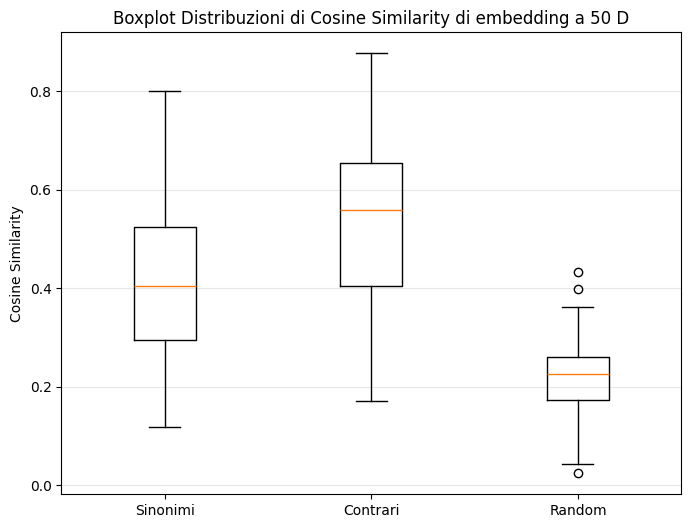

In [28]:
#BOX-Plot PCA 50 D:
#confronto tra le distribuzioni: box plot
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_50D["cosine_similarity"],
        ant_df_50D["cosine_similarity"],
        rand_df_50D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 50 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_50D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\3089064329.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


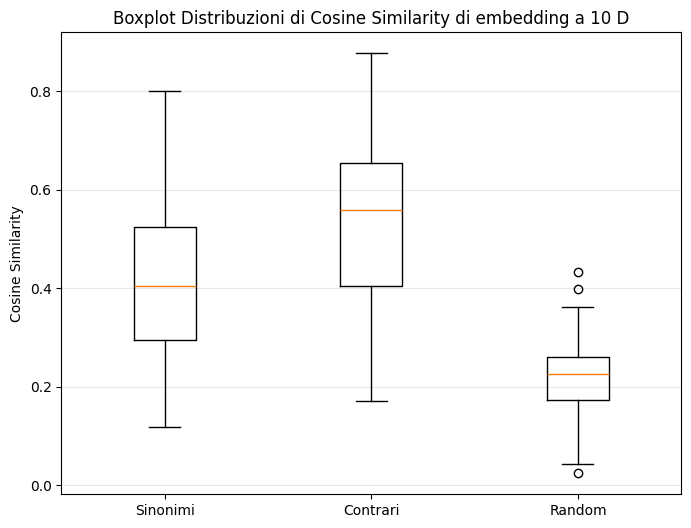

In [29]:
#BOX-Plot PCA 10 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_10D["cosine_similarity"],
        ant_df_10D["cosine_similarity"],
        rand_df_10D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 10 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_10D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\marco\AppData\Local\Temp\ipykernel_10304\951198369.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


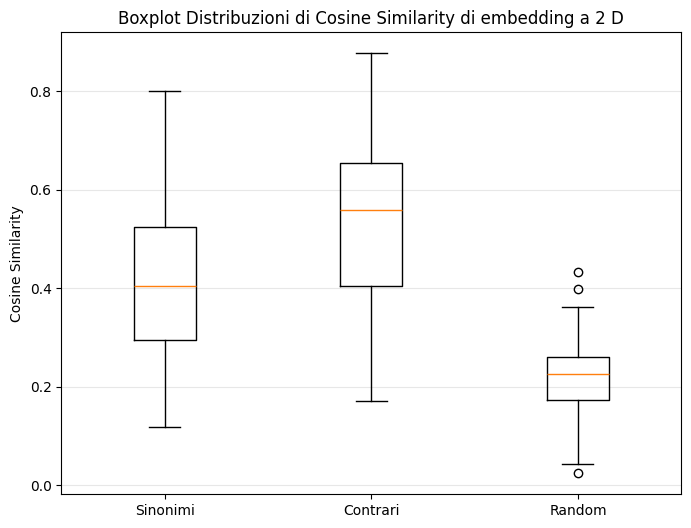

In [30]:
#BOX-Plot PCA 10 D:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        syn_df_2D["cosine_similarity"],
        ant_df_2D["cosine_similarity"],
        rand_df_2D["cosine_similarity"]
    ],
    labels=["Sinonimi", "Contrari", "Random"]
)

plt.ylabel("Cosine Similarity")
plt.title("Boxplot Distribuzioni di Cosine Similarity di embedding a 2 D")

plt.grid(axis="y", alpha=0.3)

#lo salvo
plt.savefig(
    "boxplot_cosine_similarity_2D.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()